In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import glob
import numpy as np
import s3fs
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_monthly.nc', '/tmp/ZI_79N_velseries_monthly.nc')
fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_612day.nc', '/tmp/ZI_79N_velseries_612day.nc')
fs.get('gaia/cjense/data/velocity/optical_vel/', '/tmp/')

In [57]:
monthly = xr.open_dataset('/tmp/ZI_79N_velseries_monthly.nc')
monthly

<xarray.Dataset> Size: 35MB
Dimensions:      (time: 3, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 24B 2014-12-16 ... 2015-02-14T12:00:00
    time1        (time) datetime64[ns] 24B ...
    time2        (time) datetime64[ns] 24B ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 35MB ...

In [58]:
six12 = xr.open_dataset('/tmp/ZI_79N_velseries_612day.nc')
six12

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 494, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2015-01-06T12:00:00 ... 2025-12-21...
    time1        (time) datetime64[ns] 4kB ...
    time2        (time) datetime64[ns] 4kB ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 6GB ...

In [ ]:
# List all files in optical_vel folder
optical_vel_path = '/tmp/optical_vel/'
files = sorted(glob.glob(optical_vel_path + '*.tif'))
print(f"Found {len(files)} files in {optical_vel_path}")
for f in files[:10]:
    print(f"  {f.split('/')[-1]}")

Found 380 files in /Users/cjense/Downloads/optical_vel/
  OPT_E78.95N_2000-06_ex_v03.0.tif
  OPT_E78.95N_2000-06_ey_v03.0.tif
  OPT_E78.95N_2000-06_vx_v03.0.tif
  OPT_E78.95N_2000-06_vy_v03.0.tif
  OPT_E78.95N_2000-07_ex_v03.0.tif
  OPT_E78.95N_2000-07_ey_v03.0.tif
  OPT_E78.95N_2000-07_vx_v03.0.tif
  OPT_E78.95N_2000-07_vy_v03.0.tif
  OPT_E78.95N_2000-08_ex_v03.0.tif
  OPT_E78.95N_2000-08_ey_v03.0.tif


In [60]:
# Separate files by component (vx, vy, vv)
vx_files = sorted([f for f in files if '_vx_' in f])
vy_files = sorted([f for f in files if '_vy_' in f])
vv_files = sorted([f for f in files if '_vv_' in f])

print(f"VX files: {len(vx_files)}")
print(f"VY files: {len(vy_files)}")
print(f"VV files: {len(vv_files)}")

# Open first vx and vy to check structure
if vx_files and vy_files:
    vx_sample = xr.open_dataset(vx_files[0], engine='rasterio')
    vy_sample = xr.open_dataset(vy_files[0], engine='rasterio')
    print(f"\nVX shape: {vx_sample.band_data.shape}")
    print(f"VY shape: {vy_sample.band_data.shape}")

VX files: 95
VY files: 95
VV files: 0

VX shape: (1, 577, 522)
VY shape: (1, 577, 522)


In [61]:
# Combine vx and vy to create vv (velocity magnitude) for all files
vv_combined = []

for vx_file, vy_file in zip(vx_files, vy_files):
    vx = xr.open_dataset(vx_file, engine='rasterio')
    vy = xr.open_dataset(vy_file, engine='rasterio')
    
    # Calculate velocity magnitude: vv = sqrt(vx^2 + vy^2)
    vv = np.sqrt(vx.band_data.squeeze()**2 + vy.band_data.squeeze()**2)
    
    vv_combined.append(vv)
    print(f"Processed: {vx_file.split('/')[-1]}")

print(f"\nCreated {len(vv_combined)} velocity magnitude arrays")

Processed: OPT_E78.95N_2000-06_vx_v03.0.tif
Processed: OPT_E78.95N_2000-07_vx_v03.0.tif
Processed: OPT_E78.95N_2000-08_vx_v03.0.tif
Processed: OPT_E78.95N_2000-09_vx_v03.0.tif
Processed: OPT_E78.95N_2001-06_vx_v03.0.tif
Processed: OPT_E78.95N_2002-06_vx_v03.0.tif
Processed: OPT_E78.95N_2003-07_vx_v03.0.tif
Processed: OPT_E78.95N_2004-06_vx_v03.0.tif
Processed: OPT_E78.95N_2004-07_vx_v03.0.tif
Processed: OPT_E78.95N_2005-06_vx_v03.0.tif
Processed: OPT_E78.95N_2005-07_vx_v03.0.tif
Processed: OPT_E78.95N_2006-06_vx_v03.0.tif
Processed: OPT_E78.95N_2006-07_vx_v03.0.tif
Processed: OPT_E78.95N_2006-08_vx_v03.0.tif
Processed: OPT_E78.95N_2007-03_vx_v03.0.tif
Processed: OPT_E78.95N_2007-04_vx_v03.0.tif
Processed: OPT_E78.95N_2007-06_vx_v03.0.tif
Processed: OPT_E78.95N_2007-07_vx_v03.0.tif
Processed: OPT_E78.95N_2007-08_vx_v03.0.tif
Processed: OPT_E78.95N_2008-06_vx_v03.0.tif
Processed: OPT_E78.95N_2008-07_vx_v03.0.tif
Processed: OPT_E78.95N_2009-06_vx_v03.0.tif
Processed: OPT_E78.95N_2009-07_v

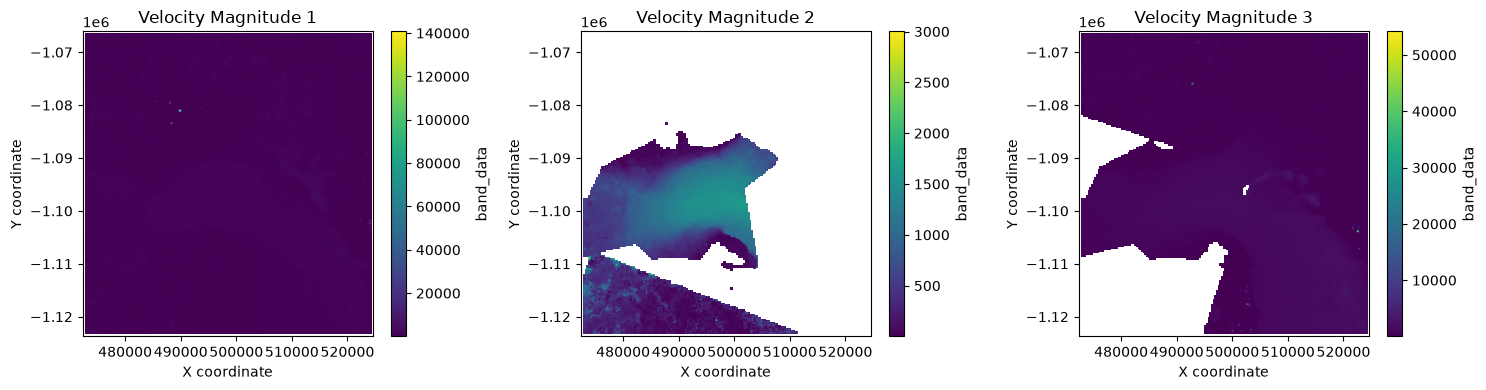

In [62]:
# Plot a few examples of the calculated velocity magnitudes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, vv in enumerate(vv_combined[:3]):
    vv.plot(ax=axes[i], cmap='viridis')
    axes[i].set_title(f'Velocity Magnitude {i+1}')
    axes[i].set_xlabel('X coordinate')
    axes[i].set_ylabel('Y coordinate')

plt.tight_layout()
plt.show()

In [63]:
# Extract time information from filenames and combine into dataset
import re
from datetime import datetime

# Extract dates from vx filenames
times = []
for vx_file in vx_files:
    filename = vx_file.split('/')[-1]
    # Extract date like "2000-06" from filename
    match = re.search(r'(\d{4})-(\d{2})', filename)
    if match:
        year, month = match.groups()
        times.append(pd.Timestamp(f"{year}-{month}-15"))
    else:
        print(f"Could not extract date from: {filename}")

print(f"Extracted {len(times)} timestamps")
for t in times[:5]:
    print(f"  {t}")

# Stack velocity magnitude arrays along time dimension
vv_stacked = xr.concat(vv_combined, dim='time')
vv_stacked['time'] = times

# Create proper dataset
vv_dataset = xr.Dataset(
    {
        'vv': vv_stacked
    },
    coords={
        'time': times,
        'y': vv_combined[0].y,
        'x': vv_combined[0].x
    }
)

print(f"\n✓ Combined velocity magnitude dataset created")
print(f"  Shape: {vv_dataset.vv.shape}")
print(f"  Time range: {vv_dataset.time.values[0]} to {vv_dataset.time.values[-1]}")
print(f"  Grid: {vv_dataset.sizes['y']} × {vv_dataset.sizes['x']}")

vv_dataset

Extracted 95 timestamps
  2000-06-15 00:00:00
  2000-07-15 00:00:00
  2000-08-15 00:00:00
  2000-09-15 00:00:00
  2001-06-15 00:00:00


/var/folders/z2/t78xbk451n74r4q5p4w1zt640000gn/T/ipykernel_86855/3035542920.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  vv_stacked = xr.concat(vv_combined, dim='time')
/var/folders/z2/t78xbk451n74r4q5p4w1zt640000gn/T/ipykernel_86855/3035542920.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  vv_stacked = xr.concat(vv_combined, dim='time')



✓ Combined velocity magnitude dataset created
  Shape: (95, 577, 522)
  Time range: 2000-06-15T00:00:00.000000 to 2014-09-15T00:00:00.000000
  Grid: 577 × 522


<xarray.Dataset> Size: 114MB
Dimensions:      (x: 522, y: 577, time: 95)
Coordinates:
  * x            (x) float64 4kB 4.724e+05 4.725e+05 ... 5.244e+05 5.245e+05
  * y            (y) float64 5kB -1.066e+06 -1.066e+06 ... -1.124e+06 -1.124e+06
  * time         (time) datetime64[us] 760B 2000-06-15 2000-07-15 ... 2014-09-15
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    vv           (time, y, x) float32 114MB nan nan nan nan ... nan nan nan nan

In [64]:
# Fix coordinate duplicates in vv_dataset
print("Checking coordinates for duplicates...")
print(f"  x unique values: {len(vv_dataset.x.values)} / {len(vv_dataset.x)}")
print(f"  y unique values: {len(vv_dataset.y.values)} / {len(vv_dataset.y)}")
print(f"  x duplicates: {len(vv_dataset.x) - len(np.unique(vv_dataset.x.values))}")
print(f"  y duplicates: {len(vv_dataset.y) - len(np.unique(vv_dataset.y.values))}")

# Remove duplicate coordinates and sort
vv_dataset_clean = vv_dataset.assign_coords({
    'x': np.unique(vv_dataset.x.values),
    'y': np.unique(vv_dataset.y.values)
})

# Reindex to match the cleaned coordinates (nearest neighbor)
vv_dataset_reindexed = vv_dataset.reindex(
    x=np.unique(vv_dataset.x.values),
    y=np.unique(vv_dataset.y.values),
    method='nearest'
)

print(f"\n✓ Cleaned vv_dataset coordinates")
print(f"  x shape: {len(vv_dataset_reindexed.x)}")
print(f"  y shape: {len(vv_dataset_reindexed.y)}")

vv_dataset = vv_dataset_reindexed

Checking coordinates for duplicates...
  x unique values: 522 / 522
  y unique values: 577 / 577
  x duplicates: 0
  y duplicates: 0

✓ Cleaned vv_dataset coordinates
  x shape: 522
  y shape: 577


In [65]:
# Inspect coordinates more carefully
print("Detailed coordinate inspection:")
print(f"  x: min={vv_dataset.x.min().values}, max={vv_dataset.x.max().values}")
print(f"  y: min={vv_dataset.y.min().values}, max={vv_dataset.y.max().values}")

# Check for actual duplicates in coordinates
x_unique, x_idx = np.unique(vv_dataset.x.values, return_index=True)
y_unique, y_idx = np.unique(vv_dataset.y.values, return_index=True)

print(f"  x unique: {len(x_unique)} / {len(vv_dataset.x)}")
print(f"  y unique: {len(y_unique)} / {len(vv_dataset.y)}")

# Reconstruct dataset with guaranteed unique, sorted coordinates
vv_data_subset = vv_dataset.vv.isel(x=x_idx, y=y_idx)

vv_dataset_fixed = xr.Dataset(
    {
        'vv': vv_data_subset
    },
    coords={
        'time': vv_dataset.time,
        'y': np.sort(y_unique),
        'x': np.sort(x_unique)
    }
)

print(f"\n✓ Reconstructed vv_dataset with unique coordinates")
print(f"  x shape: {len(vv_dataset_fixed.x)}")
print(f"  y shape: {len(vv_dataset_fixed.y)}")

vv_dataset = vv_dataset_fixed

Detailed coordinate inspection:
  x: min=472400.0, max=524500.0
  y: min=-1123700.0, max=-1066100.0
  x unique: 522 / 522
  y unique: 577 / 577

✓ Reconstructed vv_dataset with unique coordinates
  x shape: 522
  y shape: 577


In [68]:
# Prepare optical dataset for merging
print("Preparing optical dataset for merging...\n")

# Regrid optical to match monthly/six12day grid
print("Regridding optical to match monthly/six12day grid...")
optical_regridded = vv_dataset.interp(
    x=monthly.x, 
    y=monthly.y, 
    method='nearest'
)
print(f"  Regridded to shape: {optical_regridded.vv.shape}")

# Rename vv to VelocityMap to match other datasets
optical_for_merge = optical_regridded.rename({'vv': 'VelocityMap'})

# Add band dimension (optical only has velocity magnitude)
optical_for_merge['VelocityMap'] = optical_for_merge['VelocityMap'].expand_dims('band')
optical_for_merge = optical_for_merge.assign_coords(band=['vv'])

print(f"✓ Prepared optical_for_merge")
print(f"  Shape: {optical_for_merge.VelocityMap.shape}")
print(f"  Time steps: {len(optical_for_merge.time)}\n")

Preparing optical dataset for merging...

Regridding optical to match monthly/six12day grid...
  Regridded to shape: (95, 1201, 801)
✓ Prepared optical_for_merge
  Shape: (1, 95, 1201, 801)
  Time steps: 95



In [66]:
# Fix coordinate mismatch by keeping only common coordinates
print("Preparing datasets for merging...\n")

# Find common coordinates across all datasets
datasets = [monthly, six12, optical_for_merge]
all_coords = [set(ds.coords.keys()) for ds in datasets]
common_coords = set.intersection(*all_coords)

print(f"Common coordinates: {common_coords}")

# Keep only common coordinates in each dataset
monthly_clean = monthly.drop_vars([c for c in monthly.coords if c not in common_coords], errors='ignore')
six12_clean = six12.drop_vars([c for c in six12.coords if c not in common_coords], errors='ignore')
optical_clean = optical_for_merge.drop_vars([c for c in optical_for_merge.coords if c not in common_coords], errors='ignore')

# Remove time overlap: keep only monthly data before six12 starts
print("\nRemoving time overlaps...")
monthly_filtered = monthly_clean.where(monthly_clean.time < six12_clean.time.values[0], drop=True)
print(f"  Monthly (after removing overlap): {len(monthly_filtered.time)} timesteps")
print(f"  Six12day: {len(six12_clean.time)} timesteps")
print(f"  Optical: {len(optical_clean.time)} timesteps")

# Concatenate in chronological order
print("\nConcatenating datasets...")
merged = xr.concat([monthly_filtered, six12_clean, optical_clean], dim='time')
merged = merged.sortby('time')

print(f"\n✓ Merged dataset created")
print(f"  Shape: {merged.VelocityMap.shape}")
print(f"  Time range: {pd.Timestamp(merged.time.values.min())} to {pd.Timestamp(merged.time.values.max())}")
print(f"  Total timesteps: {len(merged.time)}")
print(f"  Grid: {merged.sizes['y']} × {merged.sizes['x']}")
print(f"  Bands: {list(merged.band.values)}")
nan_total = merged.VelocityMap.isnull().sum().values
total = merged.VelocityMap.size
print(f"  Valid data: {100 * (1 - nan_total / total):.1f}%")

merged

Preparing datasets for merging...

Common coordinates: {'y', 'name', 'time', 'x', 'band'}

Removing time overlaps...
  Monthly (after removing overlap): 1 timesteps
  Six12day: 494 timesteps
  Optical: 95 timesteps

Concatenating datasets...


/var/folders/z2/t78xbk451n74r4q5p4w1zt640000gn/T/ipykernel_86855/3078825350.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'band' ('band',) The recommendation is to set join explicitly for this case.
  merged = xr.concat([monthly_filtered, six12_clean, optical_clean], dim='time')



✓ Merged dataset created
  Shape: (590, 3, 1201, 801)
  Time range: 2000-06-15 00:00:00 to 2025-12-21 12:00:00
  Total timesteps: 590
  Grid: 1201 × 801
  Bands: [np.str_('vv'), np.str_('vx'), np.str_('vy')]
  Valid data: 64.0%


<xarray.Dataset> Size: 7GB
Dimensions:      (time: 590, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 5kB 2000-06-15 ... 2025-12-21T12:00:00
  * band         (band) <U2 24B 'vv' 'vx' 'vy'
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B 'None'
Data variables:
    spatial_ref  (time) float64 5kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    VelocityMap  (time, band, y, x) float32 7GB nan nan nan nan ... 0.0 0.0 0.0

In [67]:
merged.to_zarr('s3://gaia/cjense/data/velocity/ZI_79N_velseries_combined.zarr', consolidated=False, storage_options=storage_options, mode='w')

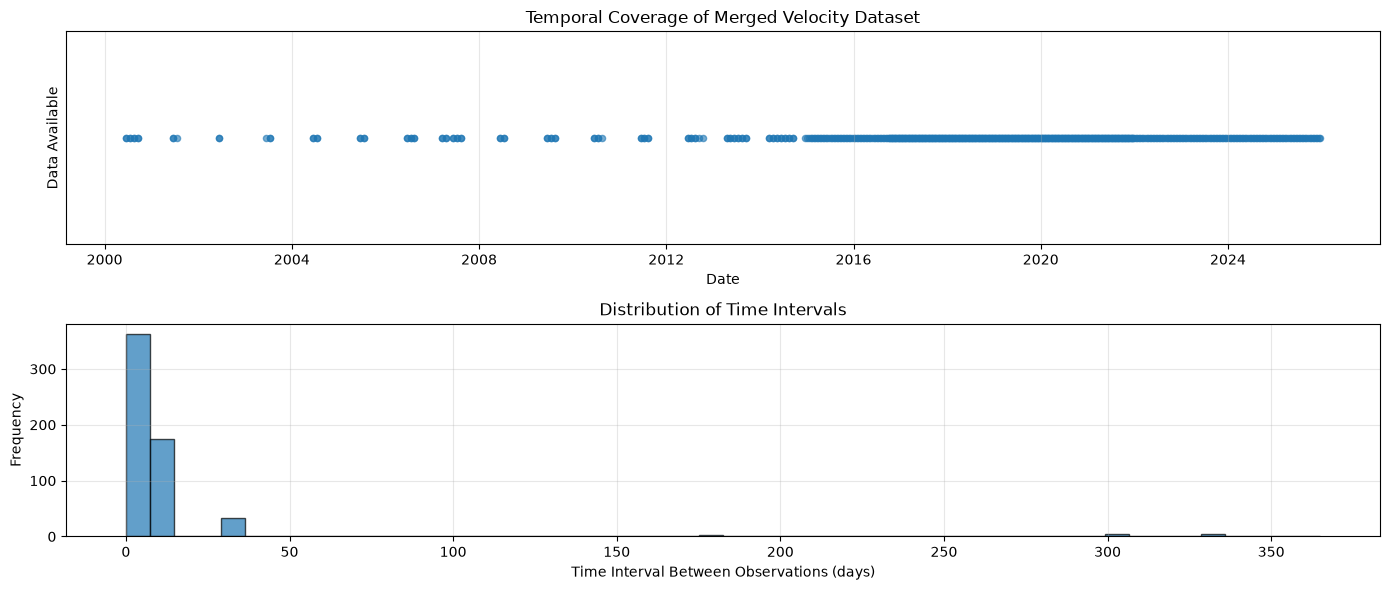

Temporal statistics:
  Total timesteps: 590
  Time span: 2000-06-15 00:00:00 to 2025-12-21 12:00:00
  Mean interval: 15.8 days
  Median interval: 6.0 days
  Min interval: 0.0 days
  Max interval: 365.0 days


In [70]:
# Plot temporal frequency of merged dataset
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Plot 1: Time series showing data availability
time_vals = merged.time.values
ax1 = axes[0]
ax1.scatter(time_vals, np.ones(len(time_vals)), alpha=0.6, s=20)
ax1.set_ylabel('Data Available')
ax1.set_xlabel('Date')
ax1.set_title('Temporal Coverage of Merged Velocity Dataset')
ax1.set_ylim(0.5, 1.5)
ax1.set_yticks([])
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram of time intervals
time_diffs = np.diff(pd.to_datetime(time_vals).astype(np.int64)) / (24 * 3600 * 1e9)  # Convert to days
ax2 = axes[1]
ax2.hist(time_diffs, bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Time Interval Between Observations (days)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Time Intervals')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Temporal statistics:")
print(f"  Total timesteps: {len(time_vals)}")
print(f"  Time span: {pd.Timestamp(time_vals[0])} to {pd.Timestamp(time_vals[-1])}")
print(f"  Mean interval: {np.mean(time_diffs):.1f} days")
print(f"  Median interval: {np.median(time_diffs):.1f} days")
print(f"  Min interval: {np.min(time_diffs):.1f} days")
print(f"  Max interval: {np.max(time_diffs):.1f} days")